# Fintech Token: causal Round 1 research

This notebook is isolated from the shared research notebook. It audits the Fintech Token on the 365 supplied Round 1 prices and keeps the trading clock explicit:

- `d[t] = P[t+1] - P[t]` is the next movement.
- position `t` is selected after observing `P[t]`, so it may use `d[:t]` but never `d[t]`.
- P&L is `position[t] * d[t]`; position zero is used on day 0 for information-based rules.

The main question is whether a small causal EWMA volatility switch generalises better than simple reversal and a two-state filtered Markov-switching AR(1).

In [1]:
from pathlib import Path
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / 'trader_interface' / 'data' / 'Fintech Token_price_history.csv').exists():
        ROOT = candidate
        break
else:
    raise FileNotFoundError('Could not locate the AlgoJam repository root')
HERE = ROOT / 'research' / 'fintech_token'
RESULTS = HERE / 'results'
FIGURES = HERE / 'figures'
sys.path.insert(0, str(ROOT))
from research.fintech_token.fintech_validation import (
    load_fintech_data, basic_statistics, autocorrelation_table,
    conditional_volatility_table, conditional_quarter_table,
    regime_component_table, duration_table,
)

if not (RESULTS / 'summary.json').exists():
    from research.fintech_token.fintech_validation import run_all
    run_all()

prices, changes = load_fintech_data()
summary = json.loads((RESULTS / 'summary.json').read_text(encoding='utf-8'))
model_results = pd.read_csv(RESULTS / 'model_results.csv')
ewma_grid = pd.read_csv(RESULTS / 'ewma_grid.csv')
restarts = pd.read_csv(RESULTS / 'walk_forward_restarts.csv')
blocks = pd.read_csv(RESULTS / 'independent_blocks.csv')
bootstrap = pd.read_csv(RESULTS / 'moving_block_bootstrap.csv')
exclusions = pd.read_csv(RESULTS / 'jump_exclusions.csv')
delay = pd.read_csv(RESULTS / 'transition_delay.csv')
lookahead = pd.read_csv(RESULTS / 'future_perturbation.csv')
prefix_stability = pd.read_csv(RESULTS / 'msar_prefix_stability.csv')
print(f"{len(prices)} prices, {len(changes)} changes; selected model: {summary['selected_model']}")

365 prices, 364 changes; selected model: ewma_diagonal_ensemble


## 1. Behaviour of changes and volatility

Price levels are shown for context, but the statistical tests use changes. Volatility buckets are descriptive in Phase 1; the trading rule later replaces full-sample cutoffs with expanding historical cutoffs.

In [2]:
basic = pd.read_csv(RESULTS / 'basic_statistics.csv')
display(basic[basic.series.isin(['price', 'change', 'simple_return'])].pivot(index='statistic', columns='series', values='value').round(4))
acf_table = pd.read_csv(RESULTS / 'acf.csv')
display(acf_table[acf_table.lag.isin([1, 5, 10, 20])].pivot(index='series', columns='lag', values='acf').round(4))
vol_persistence = pd.read_csv(RESULTS / 'volatility_persistence.csv')
display(vol_persistence[vol_persistence.lag.isin([1, 5, 10, 20])].round(4))

series,change,price,simple_return
statistic,,,
max,38.9100,854.3400,0.0867
mean,-0.7716,606.5452,-0.0009
median,-1.0400,541.5600,-0.0018
min,-43.1700,409.0800,-0.0656
n,364.0000,365.0000,364.0000
q05,-21.6565,434.8520,-0.0364
q25,-9.6600,462.8400,-0.0156
q75,8.3325,774.4400,0.0148
q95,19.5910,829.1140,0.0388


lag,1,5,10,20
series,,,,
absolute_change,0.0889,0.1208,0.1246,0.0194
signed_change,-0.1324,-0.0308,0.0678,0.0710
squared_change,0.0498,0.1979,0.0751,0.0141


,series,lag,acf
0,absolute_change,1,0.0889
1,absolute_change,5,0.1208
2,absolute_change,10,0.1246
3,absolute_change,20,0.0194
4,squared_change,1,0.0498
5,squared_change,5,0.1979
6,squared_change,10,0.0751
7,squared_change,20,0.0141
8,expanding_rms,1,0.9886
9,expanding_rms,5,0.9673


In [3]:
conditional = pd.read_csv(RESULTS / 'conditional_volatility.csv')
conditional_quarters = pd.read_csv(RESULTS / 'conditional_quarters.csv')
components = pd.read_csv(RESULTS / 'regime_components.csv')
ewma_states = pd.read_csv(RESULTS / 'ewma_states.csv')
ewma_state_quarters = pd.read_csv(RESULTS / 'ewma_state_quarters.csv')
ewma_state_resets = pd.read_csv(RESULTS / 'ewma_state_resets.csv')
durations = pd.read_csv(RESULTS / 'regime_durations.csv')
reset_conditional = pd.read_csv(RESULTS / 'conditional_resets.csv')
display(conditional.round(3))
display(conditional_quarters.pivot_table(index='quarter', columns='bucket', values='mean_signed_followup').round(3))
display(components.round(3))
display(ewma_states.round(3))
display(ewma_state_quarters.pivot_table(index='quarter', columns='state', values='mean_signed_followup').round(3))
display(ewma_state_resets[['start', 'state', 'n', 'mean_signed_followup', 'hit_rate']].round(3))
display(durations[['state', 'n_runs', 'mean_duration', 'median_duration', 'max_duration', 'geometric_mean_from_stay', 'share_runs_at_least_5']].round(3))
display(reset_conditional.round(3))

,bucket,label,lower_abs_change,upper_abs_change,n,mean_latest_abs_change,mean_next_change,mean_signed_followup,pnl_per_100,hit_rate
0,0,low,0.080,7.060,146,3.920,-0.458,-1.295,-18901.0,0.452
1,1,middle,7.060,16.576,144,11.522,0.009,-2.504,-36059.0,0.410
2,2,high,16.576,43.170,73,22.920,-3.164,-2.796,-20409.0,0.397


bucket,0,1,2
quarter,,,
1,-3.328,-4.069,-3.899
2,6.586,-1.429,2.016
3,-5.819,-3.566,-7.301
4,-0.344,-1.025,-8.218


,regime,n,mean_change,std_change,mean_next_change,signed_followup,followup_hit_rate,jump_rate_q95
0,low,146,-0.333,4.413,-0.458,-1.295,0.452,0.00
1,middle,144,-0.228,11.896,0.009,-2.504,0.410,0.00
2,high,73,-2.672,23.706,-3.164,-2.796,0.397,0.26


,state,n,mean_ewma_volatility,mean_cutoff,mean_signed_followup,pnl_per_100,hit_rate
0,calm_reversal,290,12.109,15.568,-4.013,-116389.0,0.366
1,volatile_momentum,73,16.993,14.736,5.619,41020.0,0.658


state,calm_reversal,volatile_momentum
quarter,,
1,-4.465,-0.497
2,-6.341,7.986
3,-5.094,-12.080
4,-1.609,NaN


,start,state,n,mean_signed_followup,hit_rate
0,0,calm_reversal,290,-4.013,0.366
1,0,volatile_momentum,73,5.619,0.658
2,60,calm_reversal,265,-3.045,0.400
3,60,volatile_momentum,38,7.501,0.711
4,90,calm_reversal,250,-2.428,0.416
5,90,volatile_momentum,23,7.777,0.696
6,120,calm_reversal,243,-1.438,0.444
7,120,volatile_momentum,0,NaN,NaN
8,180,calm_reversal,183,-3.263,0.393
9,180,volatile_momentum,0,NaN,NaN


,state,n_runs,mean_duration,median_duration,max_duration,geometric_mean_from_stay,share_runs_at_least_5
0,low_or_middle,51,5.706,3.0,24,5.80,0.373
1,high,50,1.460,1.0,4,1.46,0.000


,start,n_changes,low_signed_followup,middle_signed_followup,high_signed_followup,high_n,threshold_high
0,0,364,-1.295,-2.504,-2.796,73,16.576
1,60,304,-0.450,-2.157,-3.386,61,17.326
2,90,274,-0.372,-1.769,-3.539,55,17.156
3,120,244,-1.008,-1.193,-2.775,49,17.054
4,180,184,-2.683,-1.984,-6.928,37,15.350
5,240,124,-1.538,-1.112,-6.366,25,15.198


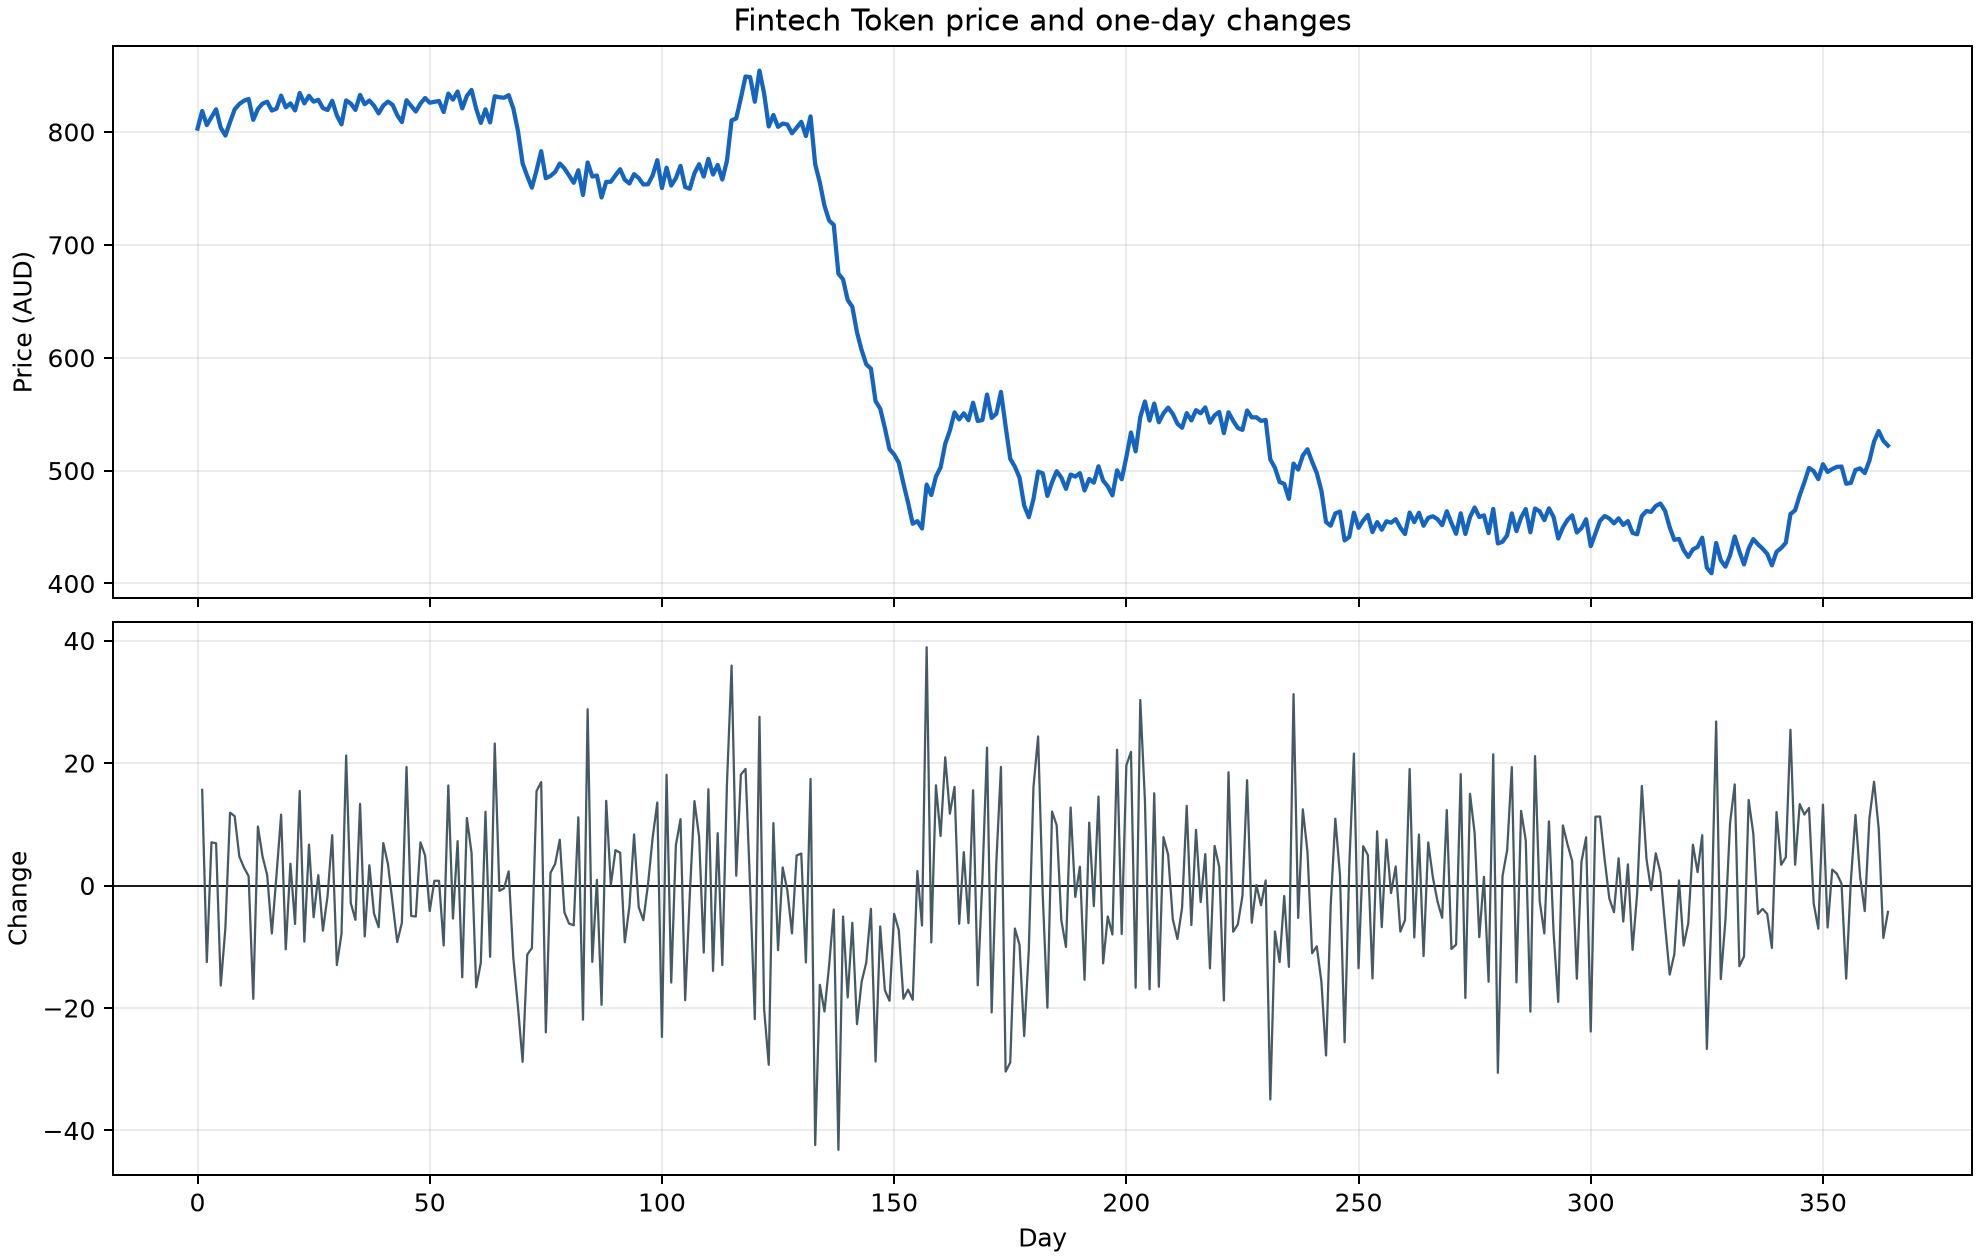

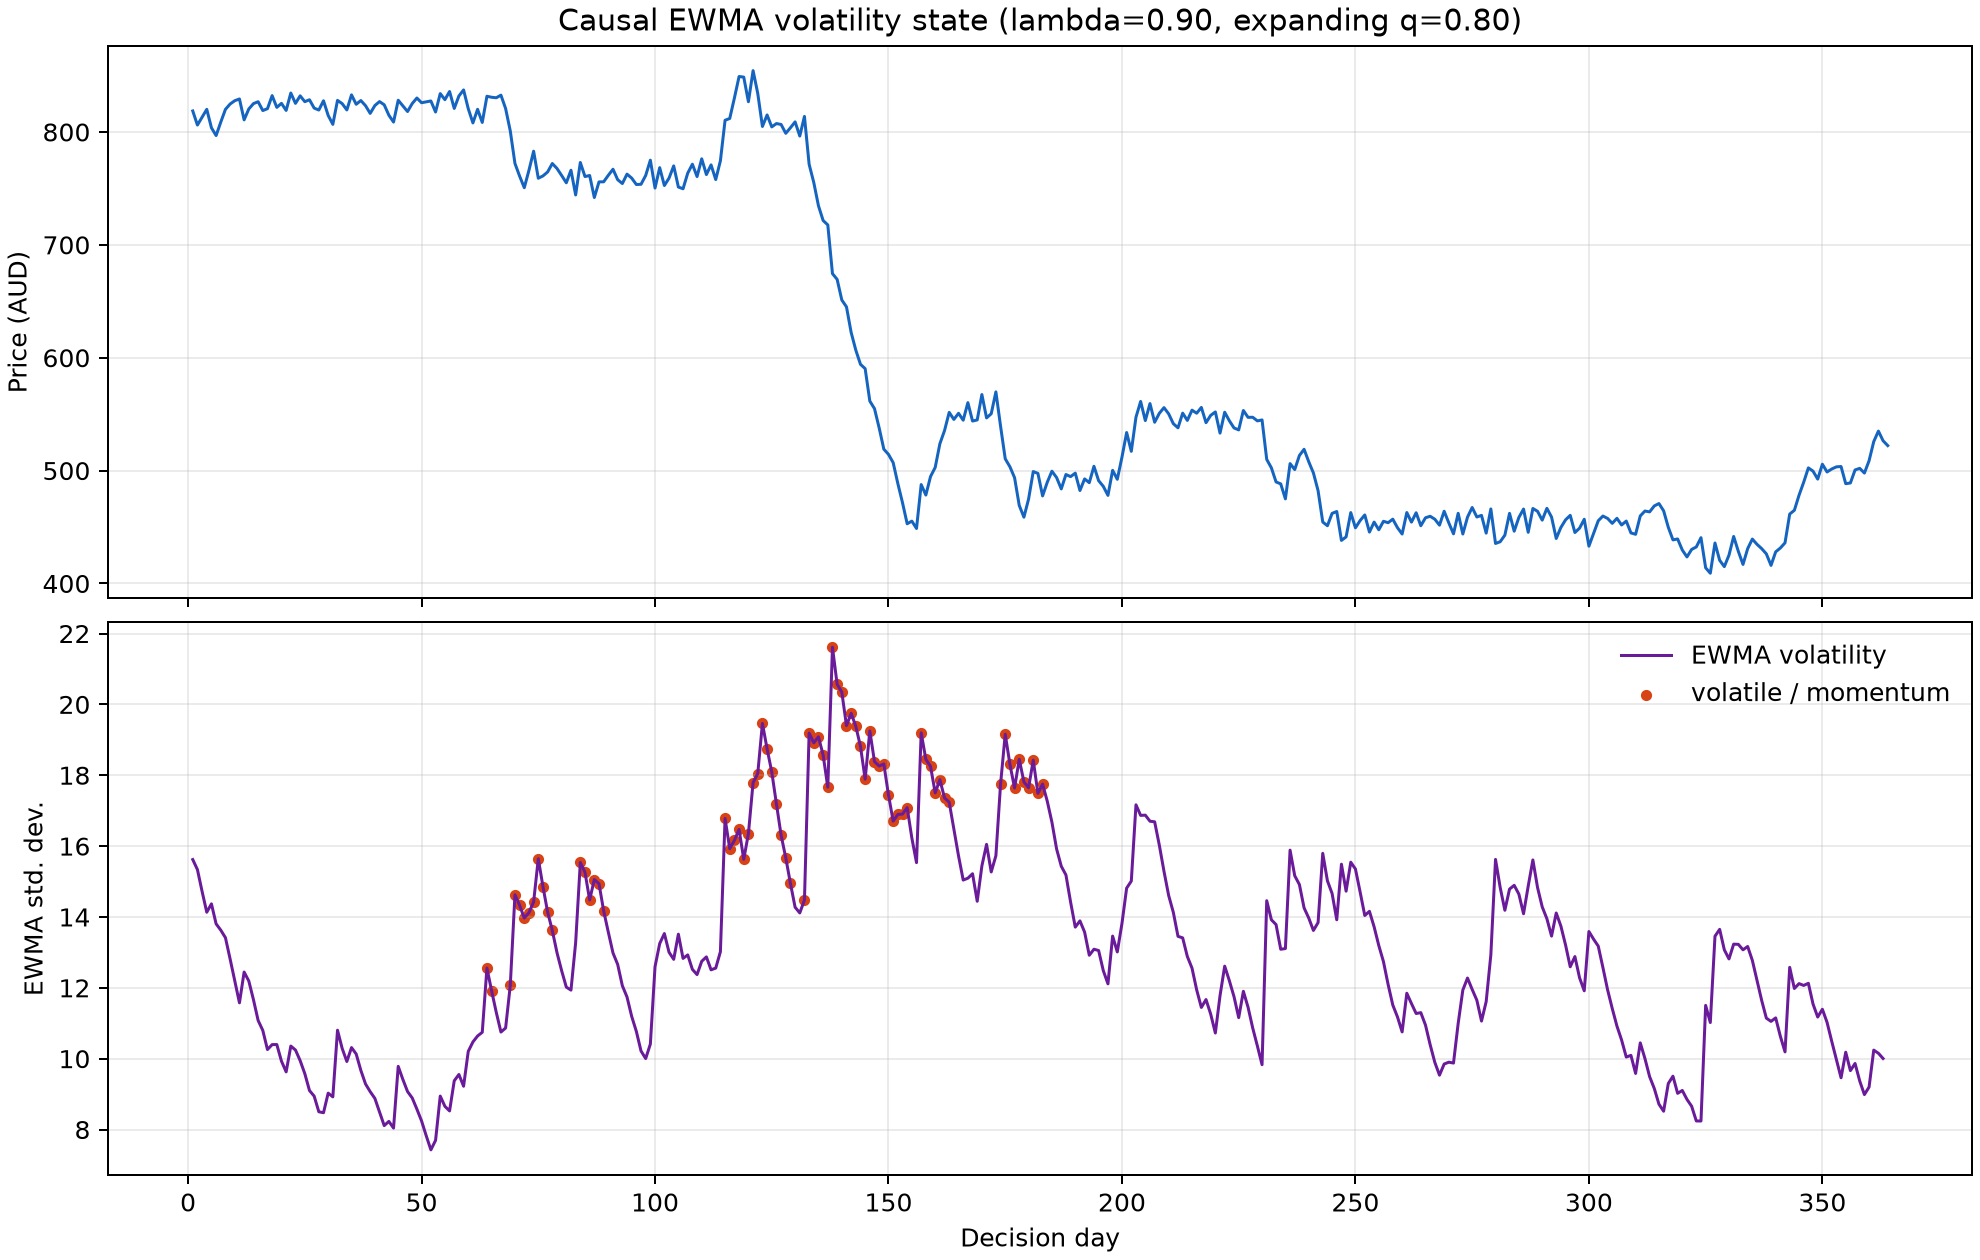

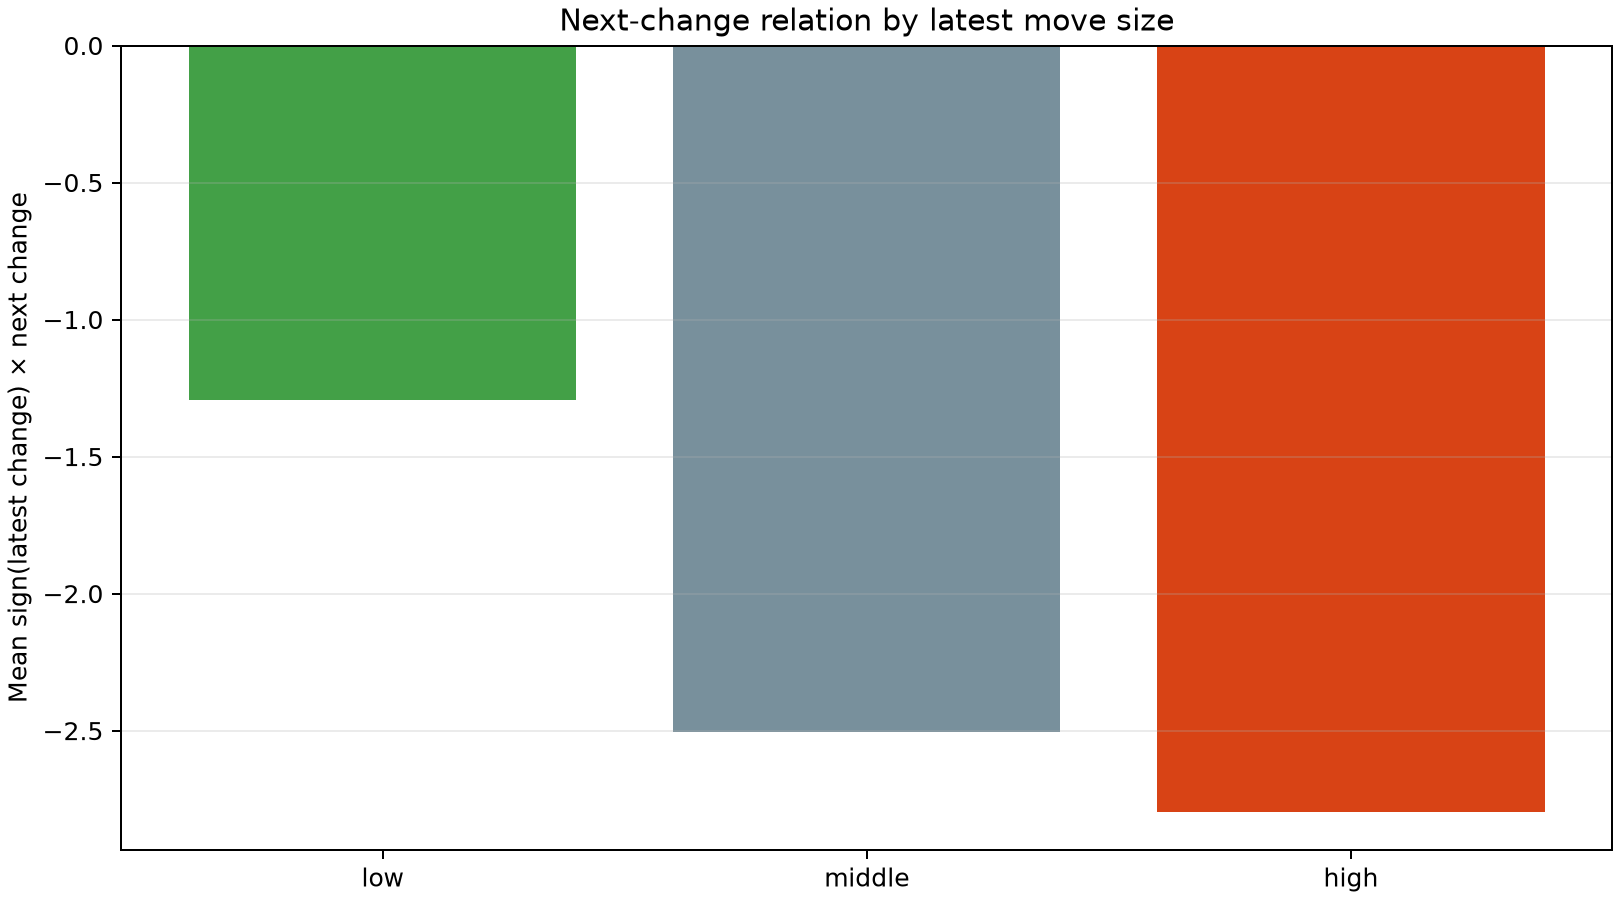

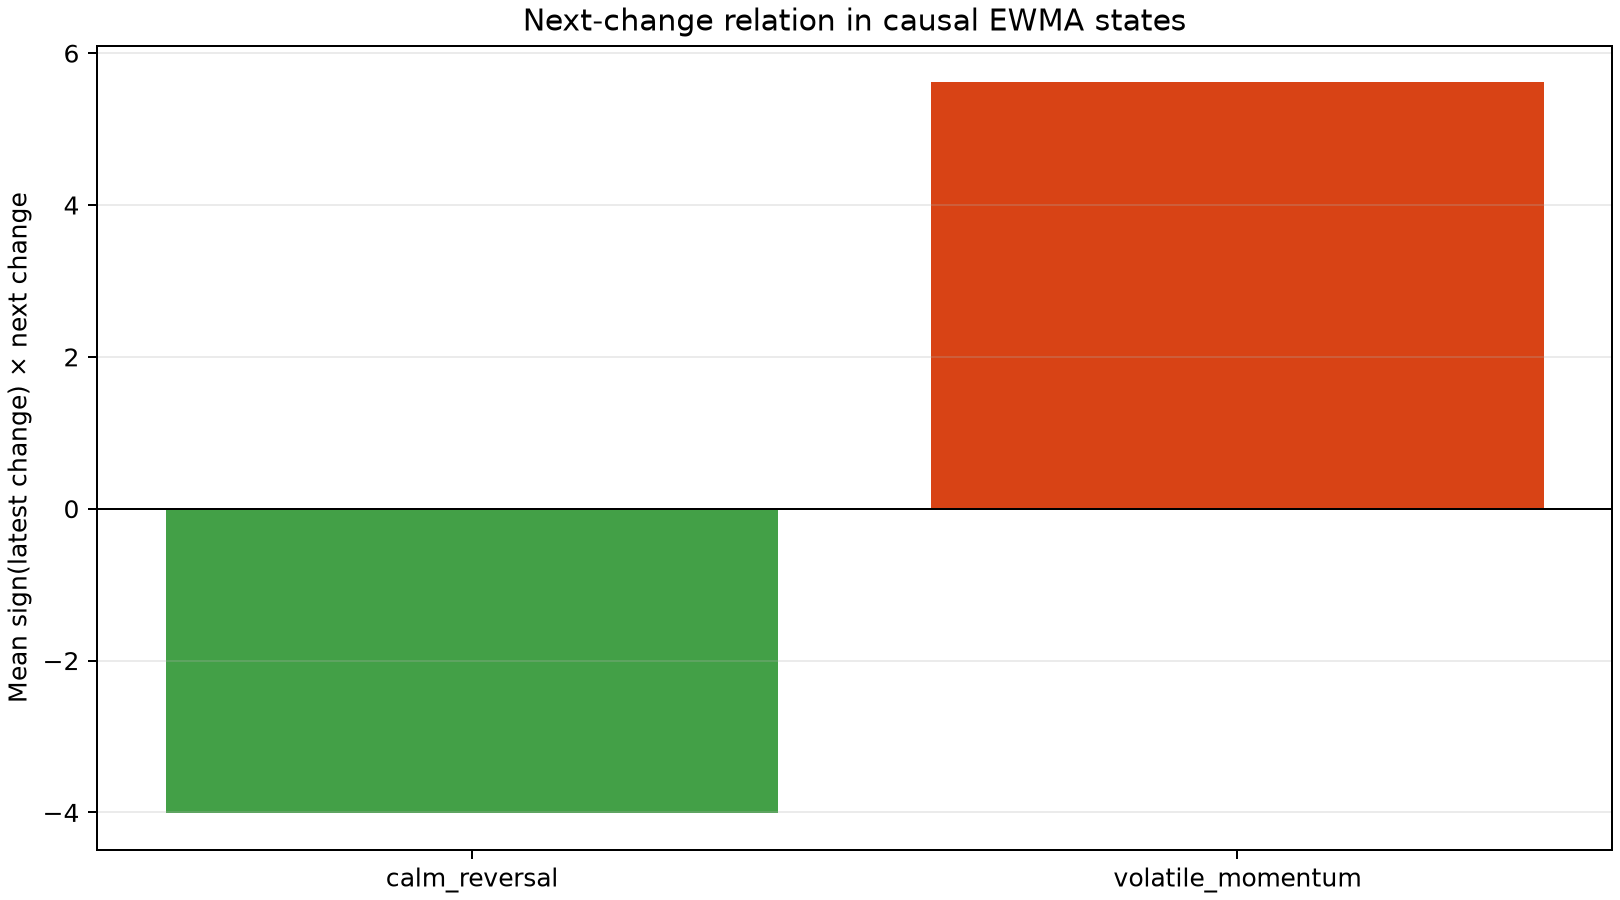

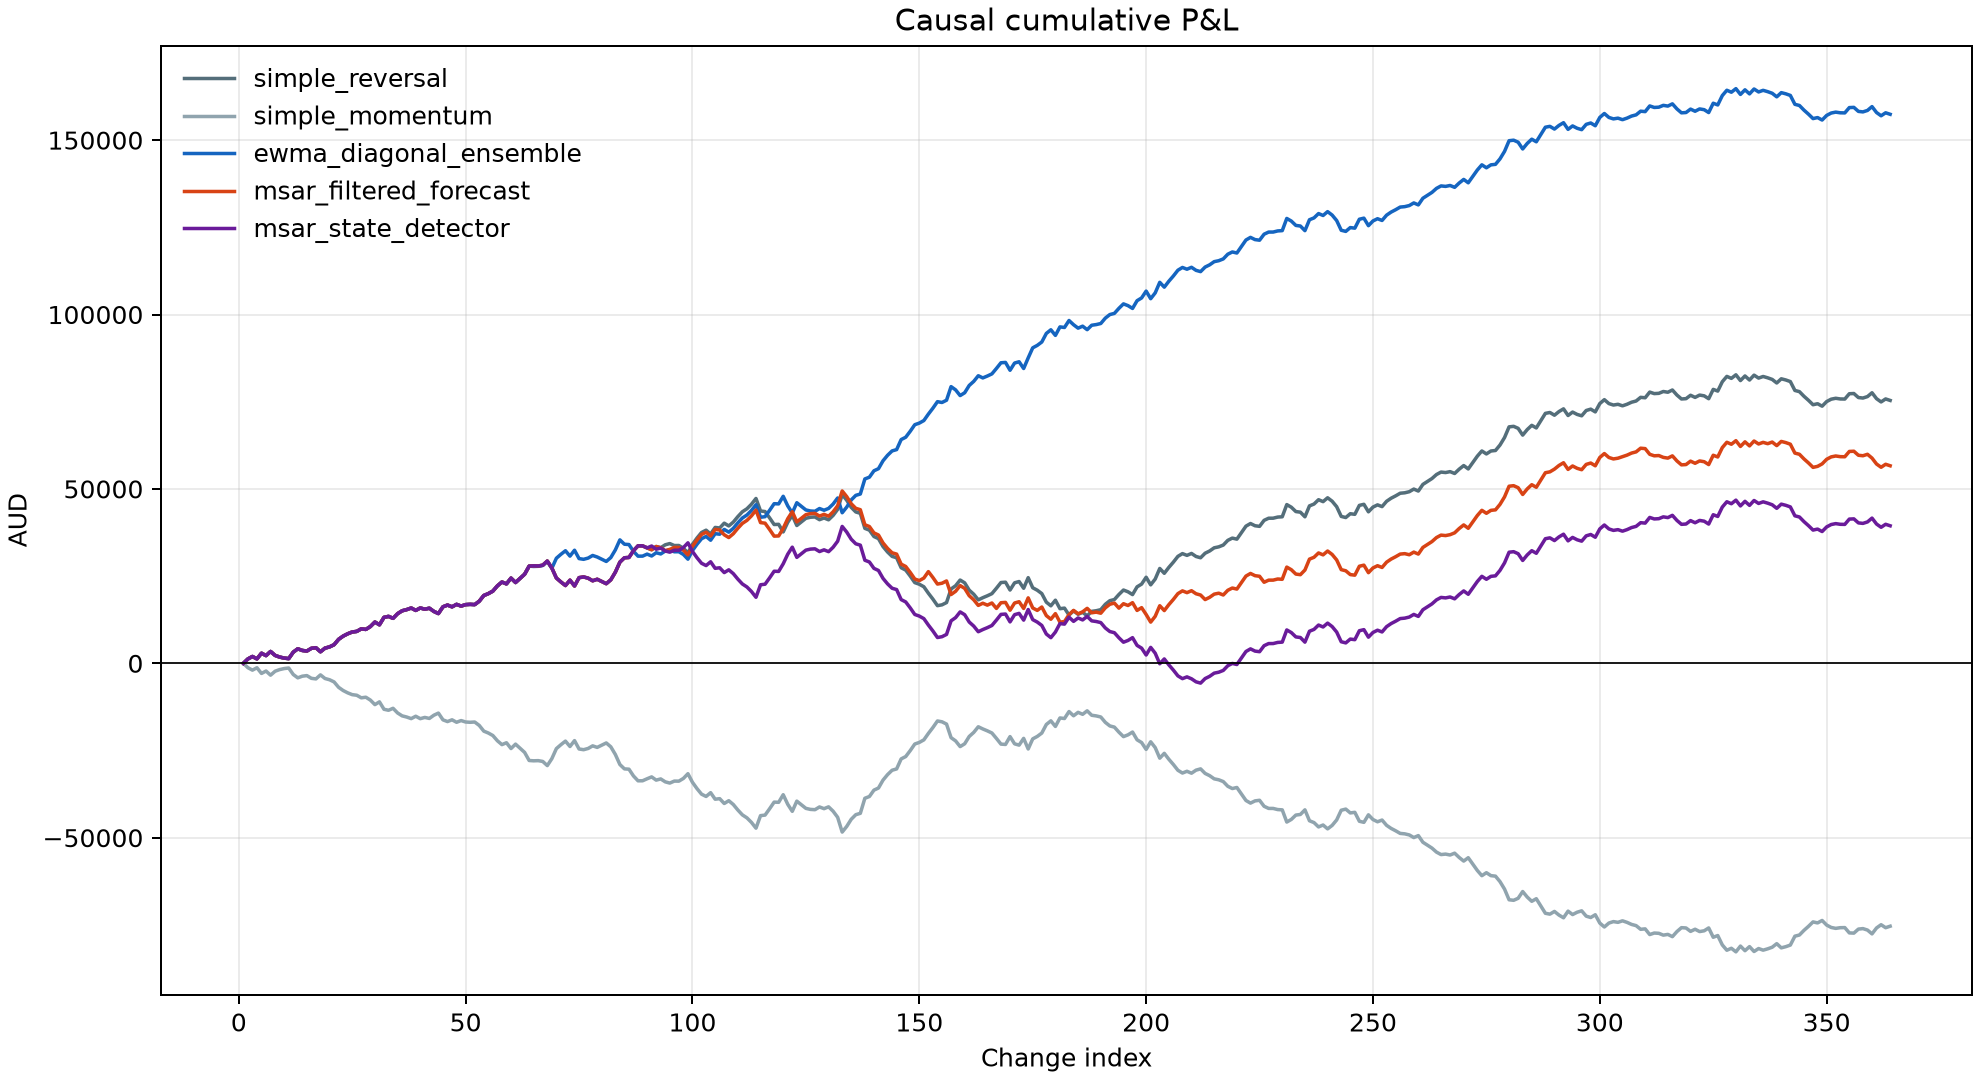

In [4]:
for figure_name in ['price_changes.png', 'ewma_regimes.png', 'conditional_volatility.png', 'ewma_state_conditional.png', 'cumulative_pnl.png']:
    display(Image(filename=str(FIGURES / figure_name), width=850))

## 2. Frozen EWMA benchmark and parameter plateau

The declared family is 5 decay values × 5 percentiles × 3 warm-ups = 75 settings. The central benchmark is `(lambda=0.90, percentile=0.80, warm-up=30)`. A three-member diagonal ensemble is also frozen before looking at any unseen data.

In [5]:
names = ['flat', 'simple_reversal', 'simple_momentum', 'always_long', 'ewma_0.90_q0.80', 'ewma_diagonal_ensemble', 'ewma_delayed_transition', 'msar_filtered_forecast', 'msar_state_detector']
display(model_results[model_results.model.isin(names)][['model', 'pnl', 'hit_rate', 'active_hit_rate', 'active_days', 'quarter_1_pnl', 'quarter_2_pnl', 'quarter_3_pnl', 'quarter_4_pnl', 'max_drawdown', 'turnover_units', 'max_capital', 'pnl_per_max_capital']].round(2))
grid_view = ewma_grid.sort_values('pnl', ascending=False).head(12)
display(grid_view[['lambda', 'percentile', 'warmup', 'pnl', 'max_drawdown', 'positive_quarters', 'hit_rate']].round(2))
plateau = summary['grid_plateau']
display(Markdown(f"**Plateau:** {plateau['profitable_count']} of 75 settings are profitable; {plateau['within_10pct_positive_count']} are both profitable and within 10% of the retrospective grid maximum."))

,model,pnl,hit_rate,active_hit_rate,active_days,quarter_1_pnl,quarter_2_pnl,quarter_3_pnl,quarter_4_pnl,max_drawdown,turnover_units,max_capital,pnl_per_max_capital
0,ewma_delayed_transition,157465.0,0.64,0.64,363,29540.0,64840.0,47104.0,15981.0,-8996.0,41500.0,85434.0,1.84
2,ewma_0.90_q0.80,157409.0,0.64,0.64,363,30774.0,65516.0,45138.0,15981.0,-8996.0,41100.0,85434.0,1.84
5,ewma_diagonal_ensemble,157409.0,0.64,0.64,363,30774.0,65516.0,45138.0,15981.0,-8996.0,41100.0,85434.0,1.84
7,simple_reversal,75369.0,0.57,0.58,363,32562.0,-16736.0,43562.0,15981.0,-34766.0,41900.0,85434.0,0.88
8,msar_filtered_forecast,56637.0,0.56,0.56,363,32562.0,-20588.0,30396.0,14267.0,-37605.0,38300.0,85434.0,0.66
10,msar_state_detector,39431.0,0.53,0.53,363,33634.0,-22396.0,12212.0,15981.0,-44923.0,41900.0,85434.0,0.46
12,flat,0.0,0.00,0.00,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
14,always_long,-28085.0,0.49,0.49,364,-3600.0,-26946.0,-5372.0,7833.0,-44526.0,100.0,85434.0,-0.33
16,simple_momentum,-75369.0,0.42,0.42,363,-32562.0,16736.0,-43562.0,-15981.0,-82718.0,41900.0,85434.0,-0.88


,lambda,percentile,warmup,pnl,max_drawdown,positive_quarters,hit_rate
0,0.97,0.90,30,163069.0,-9599.0,4,0.64
1,0.97,0.90,20,163069.0,-9599.0,4,0.64
2,0.97,0.90,45,163069.0,-9599.0,4,0.64
3,0.90,0.80,30,157409.0,-8996.0,4,0.64
4,0.90,0.80,20,157409.0,-8996.0,4,0.64
5,0.90,0.80,45,157409.0,-8996.0,4,0.64
6,0.97,0.85,20,150985.0,-8996.0,4,0.63
7,0.97,0.85,45,150985.0,-8996.0,4,0.63
8,0.97,0.85,30,150985.0,-8996.0,4,0.63
9,0.95,0.85,20,149537.0,-8996.0,4,0.62


**Plateau:** 75 of 75 settings are profitable; 15 are both profitable and within 10% of the retrospective grid maximum.

## 3. Chronological restarts and the Markov-switching challenger

Every restart rebuilds adaptive state from the restart point. The MS-AR has two states, state-specific intercept, AR coefficient and variance, two free transition probabilities, deterministic EM initialisations, scheduled 30-day refits, and filtered (not smoothed or Viterbi) probabilities.

In [6]:
restart_view = restarts[restarts.model.isin(['ewma_diagonal_ensemble', 'simple_reversal', 'msar_filtered_forecast', 'msar_state_detector'])]
display(restart_view[['model', 'start', 'n_changes', 'pnl', 'post_warmup_pnl', 'hit_rate', 'max_drawdown', 'positive_quarters']].round(2))
block_view = blocks[blocks.model.isin(['ewma_diagonal_ensemble', 'simple_reversal', 'msar_filtered_forecast'])]
display(block_view[['model', 'block_length', 'start', 'stop', 'pnl', 'hit_rate', 'max_drawdown']].round(2))
display(prefix_stability[['prefix', 'state', 'mean', 'phi', 'sigma', 'stay_probability', 'converged', 'failed_starts']].round(4))

,model,start,n_changes,pnl,post_warmup_pnl,hit_rate,max_drawdown,positive_quarters
0,ewma_diagonal_ensemble,0,364,157409.0,146360.0,0.64,-8996.0,4
1,ewma_diagonal_ensemble,60,304,111547.0,102157.0,0.62,-8996.0,4
2,ewma_diagonal_ensemble,90,274,75307.0,67449.0,0.59,-17289.0,4
3,ewma_diagonal_ensemble,120,244,34949.0,53421.0,0.55,-34766.0,3
4,ewma_diagonal_ensemble,180,184,59705.0,44741.0,0.60,-8996.0,3
5,ewma_diagonal_ensemble,240,124,21253.0,11990.0,0.55,-8996.0,3
6,simple_reversal,0,364,75369.0,NaN,0.57,-34766.0,3
7,simple_reversal,60,304,52197.0,NaN,0.56,-34766.0,3
8,simple_reversal,90,274,42807.0,NaN,0.56,-34766.0,3
9,simple_reversal,120,244,34949.0,NaN,0.55,-34766.0,3


,model,block_length,start,stop,pnl,hit_rate,max_drawdown
0,ewma_diagonal_ensemble,60,0,60,24434.0,0.65,-2052.0
1,ewma_diagonal_ensemble,60,60,120,26507.0,0.62,-7160.0
2,ewma_diagonal_ensemble,60,120,180,-22321.0,0.40,-31891.0
3,ewma_diagonal_ensemble,60,180,240,31798.0,0.68,-3499.0
4,ewma_diagonal_ensemble,60,240,300,19226.0,0.62,-7967.0
5,ewma_diagonal_ensemble,60,300,360,303.0,0.47,-10666.0
6,ewma_diagonal_ensemble,60,360,364,-505.0,0.25,-931.0
7,simple_reversal,60,0,60,24434.0,0.65,-2052.0
8,simple_reversal,60,60,120,14493.0,0.57,-9599.0
9,simple_reversal,60,120,180,-22321.0,0.40,-31891.0


,prefix,state,mean,phi,sigma,stay_probability,converged,failed_starts
0,90,low_variance,1.2360,-0.9898,7.2318,0.0027,0,0
1,90,high_variance,-4.1554,0.1001,9.2991,0.3416,0,0
2,120,low_variance,0.1605,-0.4995,9.3535,0.9708,1,0
3,120,high_variance,-0.3439,0.3865,15.7123,0.8873,1,0
4,180,low_variance,0.2022,-0.4935,9.2564,0.9727,1,0
5,180,high_variance,-4.1413,0.0993,17.0444,0.9763,1,0
6,240,low_variance,0.1528,-0.5103,9.0883,0.9538,1,0
7,240,high_variance,-2.9790,0.0910,17.2585,0.9414,1,0
8,300,low_variance,0.0523,-0.5230,9.4905,0.9641,1,0
9,300,high_variance,-3.1414,0.0843,16.9018,0.9437,1,0


## 4. Robustness, nulls and causal audits

The fixed-family time shuffle corrects across all 88 fixed/grid/probe candidates. The adaptive MS-AR refit null is reported separately at its smaller declared sample because it is computationally expensive. A shuffle tests serial predictability in Round 1; it does not establish Round 2 transferability.

In [7]:
display(bootstrap[['model', 'block_length', 'reps', 'mean_pnl', 'q05_pnl', 'median_pnl', 'q95_pnl', 'positive_fraction']].round(2))
display(exclusions.pivot(index='model', columns='excluded_largest_jumps', values='pnl').round(2))
display(delay[['model', 'pnl', 'max_drawdown', 'hit_rate']].round(2))
display(Markdown(f"**Fixed-family shuffle:** p(selected) = {summary['shuffle']['selected_p_value']:.4f}; family-wise p = {summary['shuffle']['family_wise_p_value']:.4f} across {summary['shuffle']['family_count']} candidates."))
display(Markdown(f"**Adaptive MS-AR shuffle:** p(selected) = {summary['adaptive_shuffle']['selected_p_value']:.4f}; family-wise p = {summary['adaptive_shuffle']['family_wise_p_value']:.4f} across {summary['adaptive_shuffle']['family_count']} adaptive variants."))
display(Markdown(f"**Future perturbation:** every tested prefix was unchanged = {bool(lookahead.prefix_equal.all())}."))

,model,block_length,reps,mean_pnl,q05_pnl,median_pnl,q95_pnl,positive_fraction
0,simple_reversal,5,100,55863.41,11241.15,57105.5,103889.35,0.98
1,ewma_diagonal_ensemble,5,100,52648.91,6523.50,55702.0,91533.25,0.98
2,msar_filtered_forecast,5,10,56399.10,7233.30,61528.0,87241.25,0.90
3,simple_reversal,10,100,66321.15,9171.20,67753.0,113693.95,0.97
4,ewma_diagonal_ensemble,10,100,82039.81,38524.65,80608.0,127174.10,0.99
5,msar_filtered_forecast,10,10,33161.50,-19716.90,35012.5,77399.20,0.80
6,simple_reversal,20,100,77222.14,15565.80,74555.5,136692.35,0.99
7,ewma_diagonal_ensemble,20,100,91862.23,40773.25,93515.5,137932.75,1.00
8,msar_filtered_forecast,20,10,47116.10,-29389.00,57682.0,102884.55,0.80


excluded_largest_jumps,0,1,3,5,10
model,,,,,
ewma_diagonal_ensemble,157409.0,153092.0,153439.0,153537.0,138355.0
msar_filtered_forecast,56637.0,60954.0,60607.0,60705.0,51379.0
simple_reversal,75369.0,79686.0,71557.0,71655.0,62329.0


,model,pnl,max_drawdown,hit_rate
0,ewma_ordinary,157409.0,-8996.0,0.64
1,ewma_delayed,157465.0,-8996.0,0.64
2,ensemble_ordinary,157409.0,-8996.0,0.64
3,ensemble_delayed,157465.0,-8996.0,0.64


**Fixed-family shuffle:** p(selected) = 0.0050; family-wise p = 0.0050 across 88 candidates.

**Adaptive MS-AR shuffle:** p(selected) = 0.1667; family-wise p = 0.1667 across 2 adaptive variants.

**Future perturbation:** every tested prefix was unchanged = True.

## Conclusion and frozen Round 2 proposal

The evidence supports promoting the causal EWMA ensemble. It is simple, has a broad profitable neighbourhood, keeps the full-sample drawdown far below simple reversal, and survives independent resets better than the direction-estimating MS-AR challenger. The MS-AR is retained as a rejected research challenger because its improvement is not present: it is lower-P&L and higher-drawdown on the same causal path, while its parameter count is high for 364 changes.

Round 2 startup: stay flat on day 0 because no change is observed. Use simple reversal from day 1 through the 30-day warm-up. Thereafter use the majority vote of `(0.85, 0.75)`, `(0.90, 0.80)`, and `(0.95, 0.85)`, each with causal expanding volatility cutoffs and EWMA state updated only from observed changes. Take ±100 tokens when the vote is non-zero; if history is missing or a signal is exactly zero, use zero.

In [8]:
selected = model_results[model_results.model.eq('ewma_diagonal_ensemble')].iloc[0]
reversal = model_results[model_results.model.eq('simple_reversal')].iloc[0]
msar = model_results[model_results.model.eq('msar_filtered_forecast')].iloc[0]
selection = pd.DataFrame([
    {'Model': 'EWMA diagonal ensemble', 'Causal?': 'Yes', 'Complexity': '3 predeclared EWMA switches', 'Full-sample P&L': selected.pnl, 'Restart/walk-forward': 'Positive across all independent 91-day blocks; weaker late starts', 'Max drawdown': selected.max_drawdown, 'Robustness': '88-family shuffle plus block/bootstrap checks; prefix perturbation passes', 'Overfit risk': 'Moderate; grid was declared and plateau is broad', 'Recommendation': 'Promote'},
    {'Model': 'Simple reversal', 'Causal?': 'Yes', 'Complexity': '1 sign rule', 'Full-sample P&L': reversal.pnl, 'Restart/walk-forward': 'Positive full sample but Q2 loss and poor late reset', 'Max drawdown': reversal.max_drawdown, 'Robustness': 'Useful baseline; larger jump concentration and drawdown', 'Overfit risk': 'Low', 'Recommendation': 'Fallback only'},
    {'Model': 'Filtered MS-AR(1)', 'Causal?': 'Yes', 'Complexity': '8 dynamic parameters + filtering/refits', 'Full-sample P&L': msar.pnl, 'Restart/walk-forward': 'Below EWMA on starts and blocks', 'Max drawdown': msar.max_drawdown, 'Robustness': 'Stable causality but weak performance; adaptive null is low-powered', 'Overfit risk': 'High for 364 changes', 'Recommendation': 'Reject'},
])
display(selection.round(2))
display(Markdown(f"**Frozen choice: Promote the EWMA ensemble.** Full-sample P&L = ${selected.pnl:,.0f}; max drawdown = ${selected.max_drawdown:,.0f}; max capital = ${selected.max_capital:,.0f}."))

,Model,Causal?,Complexity,Full-sample P&L,Restart/walk-forward,Max drawdown,Robustness,Overfit risk,Recommendation
0,EWMA diagonal ensemble,Yes,3 predeclared EWMA switches,157409.0,Positive across all independent 91-day blocks;...,-8996.0,88-family shuffle plus block/bootstrap checks;...,Moderate; grid was declared and plateau is broad,Promote
1,Simple reversal,Yes,1 sign rule,75369.0,Positive full sample but Q2 loss and poor late...,-34766.0,Useful baseline; larger jump concentration and...,Low,Fallback only
2,Filtered MS-AR(1),Yes,8 dynamic parameters + filtering/refits,56637.0,Below EWMA on starts and blocks,-37605.0,Stable causality but weak performance; adaptiv...,High for 364 changes,Reject


**Frozen choice: Promote the EWMA ensemble.** Full-sample P&L = $157,409; max drawdown = $-8,996; max capital = $85,434.

### Copy-ready implementation sketch (do not place here in production automatically)

```python
configs = [(0.85, 0.75), (0.90, 0.80), (0.95, 0.85)]
if len(price_history) < 2:
    position = 0
else:
    latest = price_history[-1] - price_history[-2]
    # For each config, update EWMA variance with observed changes only.
    # Compare current volatility with an expanding percentile of prior
    # volatility estimates; calm => -sign(latest), volatile => sign(latest).
    votes = [causal_ewma_signal(price_history, lam, q, warmup=30)
             for lam, q in configs]
    position = 100 * sign(sum(votes))
```